# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Vape Zyn Nicotine Dataset](https://www.kaggle.com/datasets/samartalwar/vape-and-zyn-shock-nicotine-heart-rate-and-panic)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/samartalwar/vape-and-zyn-shock-nicotine-heart-rate-and-panic/vape_zyn_nicotine_cardiac_panic.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('vape_zyn_nicotine_cardiac_panic.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,user_id,age,gender,primary_product,years_of_use,daily_units_consumed,absorbed_nicotine_mg,usage_frequency_per_hour,caffeine_mg,morning_craving_latency_min,baseline_resting_hr,heart_rate_spike_bpm,peak_heart_rate_bpm,systolic_bp_spike_mmhg,jitters_intensity_score,subjective_anxiety_score,acute_panic_attack_flag,nicotine_dependence_index,cardiac_anxiety_tier
0,NIC-00001,24,Male,Nicotine Pouch (6mg Zyn/Velo),3.3,20,65.2,1.2,321,26,64.9,27.4,92.3,15.2,7.8,8.9,0,71.6,High Tachycardia & Jitters
1,NIC-00002,44,Male,Nicotine Pouch (6mg Zyn/Velo),9.7,18,55.2,1.1,104,21,67.7,17.6,85.3,9.7,5.9,7.0,0,75.1,High Tachycardia & Jitters
2,NIC-00003,33,Male,Nicotine Pouch (9-12mg Strong),10.1,12,58.0,0.8,205,22,75.2,22.8,98.0,12.8,6.0,8.2,1,71.3,High Tachycardia & Jitters
3,NIC-00004,29,Non-Binary,Refillable Pod Vape (20-30mg/mL),3.4,178,13.3,11.1,34,46,62.9,10.4,73.3,8.1,1.3,4.7,0,36.9,Moderate Autonomic Arousal
4,NIC-00005,20,Male,Nicotine Pouch (9-12mg Strong),1.3,3,15.1,0.2,282,58,71.7,16.5,88.2,11.3,4.2,6.9,0,29.0,High Tachycardia & Jitters


## last Five row

In [4]:
df.tail()

,user_id,age,gender,primary_product,years_of_use,daily_units_consumed,absorbed_nicotine_mg,usage_frequency_per_hour,caffeine_mg,morning_craving_latency_min,baseline_resting_hr,heart_rate_spike_bpm,peak_heart_rate_bpm,systolic_bp_spike_mmhg,jitters_intensity_score,subjective_anxiety_score,acute_panic_attack_flag,nicotine_dependence_index,cardiac_anxiety_tier
8495,NIC-08496,47,Male,Refillable Pod Vape (20-30mg/mL),16.1,454,31.4,28.4,291,18,72.8,29.4,102.2,18.4,5.7,9.3,0,62.6,High Tachycardia & Jitters
8496,NIC-08497,49,Male,Nicotine Pouch (3mg Zyn/Velo),16.8,3,4.4,0.2,316,37,63.5,7.6,71.1,8.4,4.5,5.6,0,43.0,Moderate Autonomic Arousal
8497,NIC-08498,28,Female,Disposable Salt-Nic Vape (50mg/mL),3.4,210,28.0,13.1,33,36,54.8,14.4,69.2,10.2,2.8,6.2,1,47.2,Moderate Autonomic Arousal
8498,NIC-08499,20,Female,Nicotine Pouch (6mg Zyn/Velo),1.6,7,21.5,0.4,216,52,69.7,9.8,79.5,9.6,3.9,5.4,0,34.9,Moderate Autonomic Arousal
8499,NIC-08500,23,Male,Nicotine Pouch (3mg Zyn/Velo),3.3,19,27.4,1.2,291,31,68.8,17.4,86.2,8.4,5.5,6.0,0,49.8,Moderate Autonomic Arousal


## Shape of our dataset

In [5]:
df.shape

(8500, 19)

## List out all columns

In [6]:
df.columns

Index(['user_id', 'age', 'gender', 'primary_product', 'years_of_use',
       'daily_units_consumed', 'absorbed_nicotine_mg',
       'usage_frequency_per_hour', 'caffeine_mg',
       'morning_craving_latency_min', 'baseline_resting_hr',
       'heart_rate_spike_bpm', 'peak_heart_rate_bpm', 'systolic_bp_spike_mmhg',
       'jitters_intensity_score', 'subjective_anxiety_score',
       'acute_panic_attack_flag', 'nicotine_dependence_index',
       'cardiac_anxiety_tier'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

user_id                         object
age                              int64
gender                          object
primary_product                 object
years_of_use                   float64
daily_units_consumed             int64
absorbed_nicotine_mg           float64
usage_frequency_per_hour       float64
caffeine_mg                      int64
morning_craving_latency_min      int64
baseline_resting_hr            float64
heart_rate_spike_bpm           float64
peak_heart_rate_bpm            float64
systolic_bp_spike_mmhg         float64
jitters_intensity_score        float64
subjective_anxiety_score       float64
acute_panic_attack_flag          int64
nicotine_dependence_index      float64
cardiac_anxiety_tier            object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      8500 non-null   object 
 1   age                          8500 non-null   int64  
 2   gender                       8500 non-null   object 
 3   primary_product              8500 non-null   object 
 4   years_of_use                 8500 non-null   float64
 5   daily_units_consumed         8500 non-null   int64  
 6   absorbed_nicotine_mg         8500 non-null   float64
 7   usage_frequency_per_hour     8500 non-null   float64
 8   caffeine_mg                  8500 non-null   int64  
 9   morning_craving_latency_min  8500 non-null   int64  
 10  baseline_resting_hr          8500 non-null   float64
 11  heart_rate_spike_bpm         8500 non-null   float64
 12  peak_heart_rate_bpm          8500 non-null   float64
 13  systolic_bp_spike_

## Check Null Value

In [9]:
df.isnull().sum()

user_id                        0
age                            0
gender                         0
primary_product                0
years_of_use                   0
daily_units_consumed           0
absorbed_nicotine_mg           0
usage_frequency_per_hour       0
caffeine_mg                    0
morning_craving_latency_min    0
baseline_resting_hr            0
heart_rate_spike_bpm           0
peak_heart_rate_bpm            0
systolic_bp_spike_mmhg         0
jitters_intensity_score        0
subjective_anxiety_score       0
acute_panic_attack_flag        0
nicotine_dependence_index      0
cardiac_anxiety_tier           0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,years_of_use,daily_units_consumed,absorbed_nicotine_mg,usage_frequency_per_hour,caffeine_mg,morning_craving_latency_min,baseline_resting_hr,heart_rate_spike_bpm,peak_heart_rate_bpm,systolic_bp_spike_mmhg,jitters_intensity_score,subjective_anxiety_score,acute_panic_attack_flag,nicotine_dependence_index
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,28.106471,4.427235,147.840706,23.540235,9.216541,201.122588,42.349176,68.026435,16.002859,84.029294,9.789141,4.326882,6.649565,0.330353,43.668282
std,7.915073,3.690332,173.039859,16.527828,10.717388,123.470041,15.806274,6.510977,9.283599,11.279572,5.184002,1.423137,1.709554,0.470368,14.743296
min,18.000000,0.500000,2.000000,3.000000,0.200000,3.000000,5.000000,52.000000,3.000000,55.000000,2.000000,1.000000,2.100000,0.000000,6.600000
25%,22.000000,1.600000,6.000000,11.100000,0.400000,108.000000,31.000000,63.600000,9.100000,76.100000,5.900000,3.300000,5.400000,0.000000,33.000000
50%,26.000000,3.400000,71.000000,19.400000,4.400000,177.000000,40.000000,68.000000,14.200000,82.900000,9.100000,4.100000,6.500000,0.000000,42.600000
75%,33.000000,6.200000,259.000000,31.700000,16.200000,269.000000,52.000000,72.400000,21.000000,90.900000,12.900000,5.200000,7.800000,1.000000,52.700000
max,50.000000,20.000000,850.000000,95.000000,45.000000,600.000000,96.000000,88.000000,48.000000,130.300000,31.800000,10.000000,10.000000,1.000000,99.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

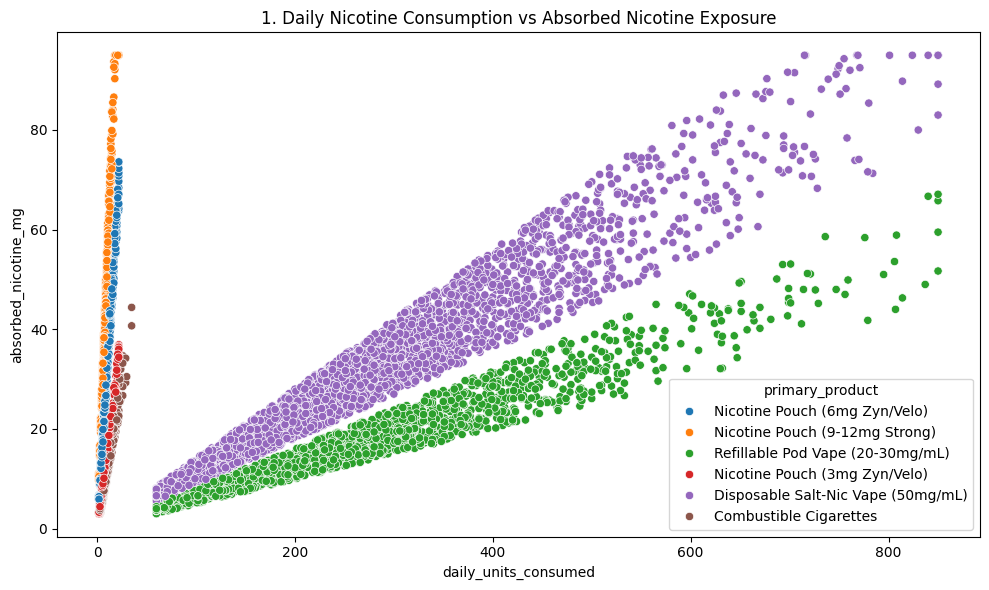

In [13]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='daily_units_consumed', y='absorbed_nicotine_mg', hue='primary_product')
plt.title(f'{plot_no}. Daily Nicotine Consumption vs Absorbed Nicotine Exposure')
show_fig()
plot_no += 1

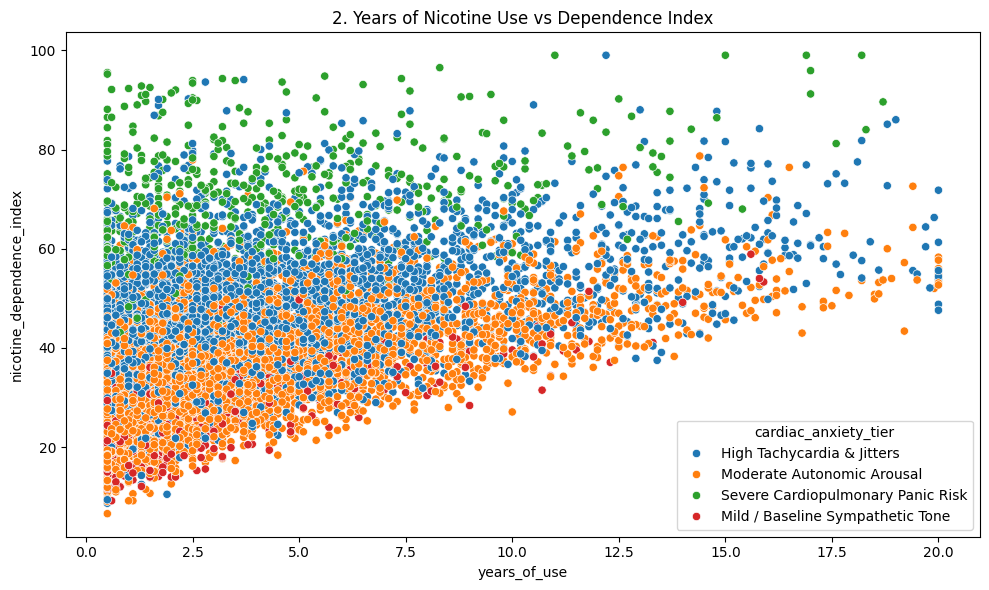

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_of_use', y='nicotine_dependence_index', hue='cardiac_anxiety_tier')
plt.title(f'{plot_no}. Years of Nicotine Use vs Dependence Index')
show_fig()
plot_no += 1

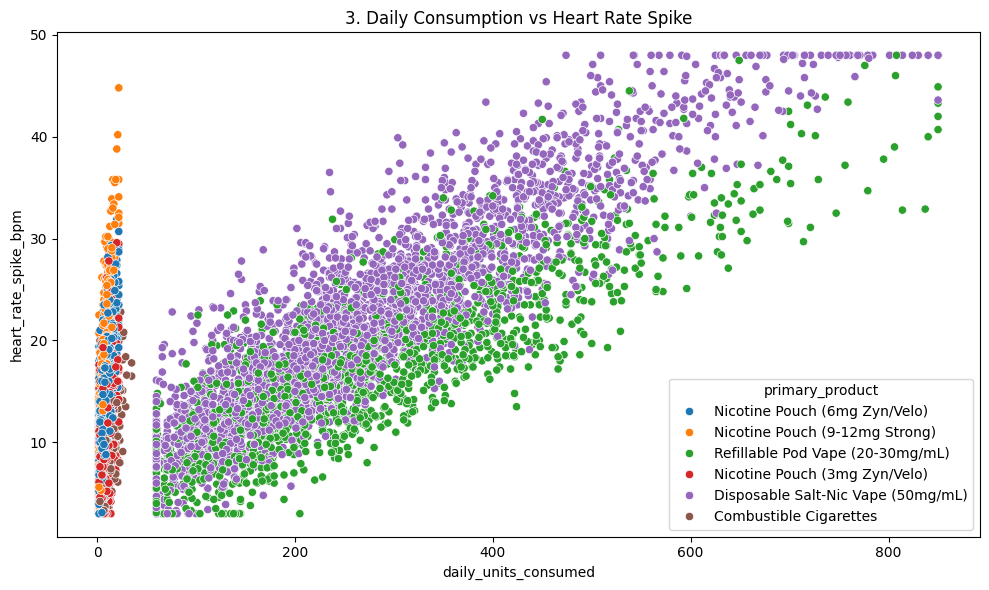

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='daily_units_consumed', y='heart_rate_spike_bpm', hue='primary_product')
plt.title(f'{plot_no}. Daily Consumption vs Heart Rate Spike')
show_fig()
plot_no += 1

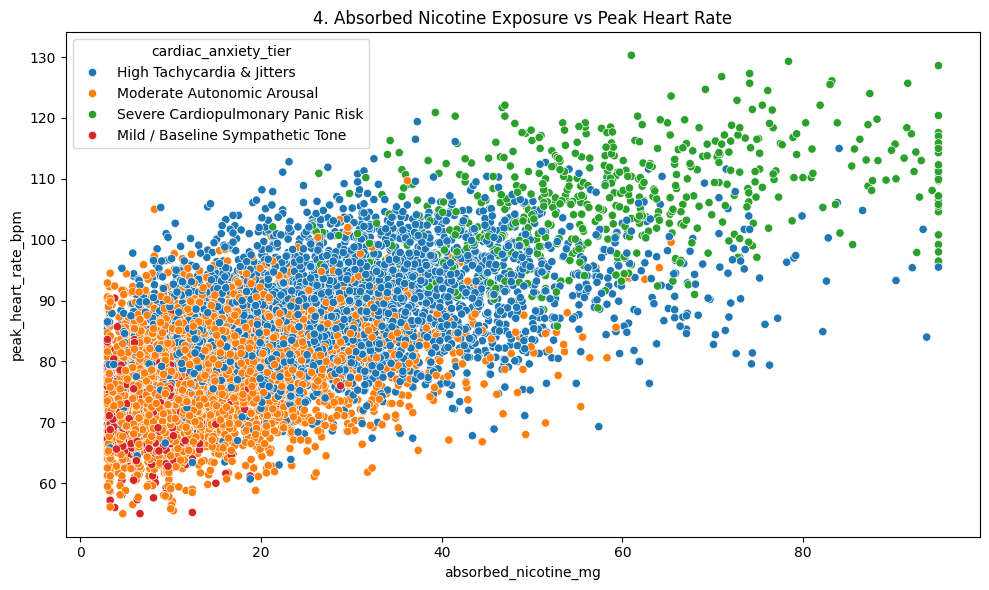

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='absorbed_nicotine_mg', y='peak_heart_rate_bpm', hue='cardiac_anxiety_tier')
plt.title(f'{plot_no}. Absorbed Nicotine Exposure vs Peak Heart Rate')
show_fig()
plot_no += 1

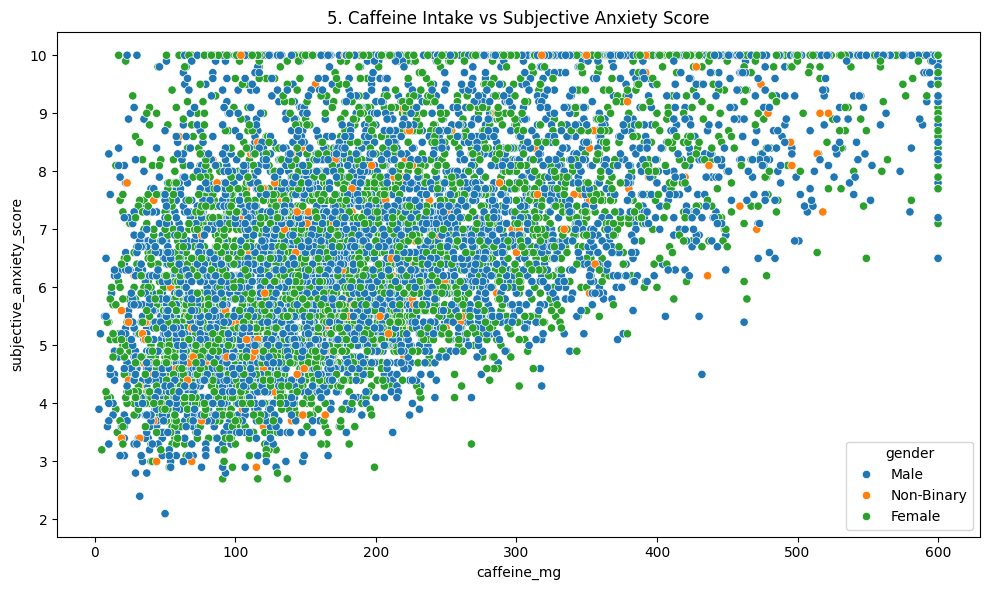

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='caffeine_mg', y='subjective_anxiety_score', hue='gender')
plt.title(f'{plot_no}. Caffeine Intake vs Subjective Anxiety Score')
show_fig()
plot_no += 1

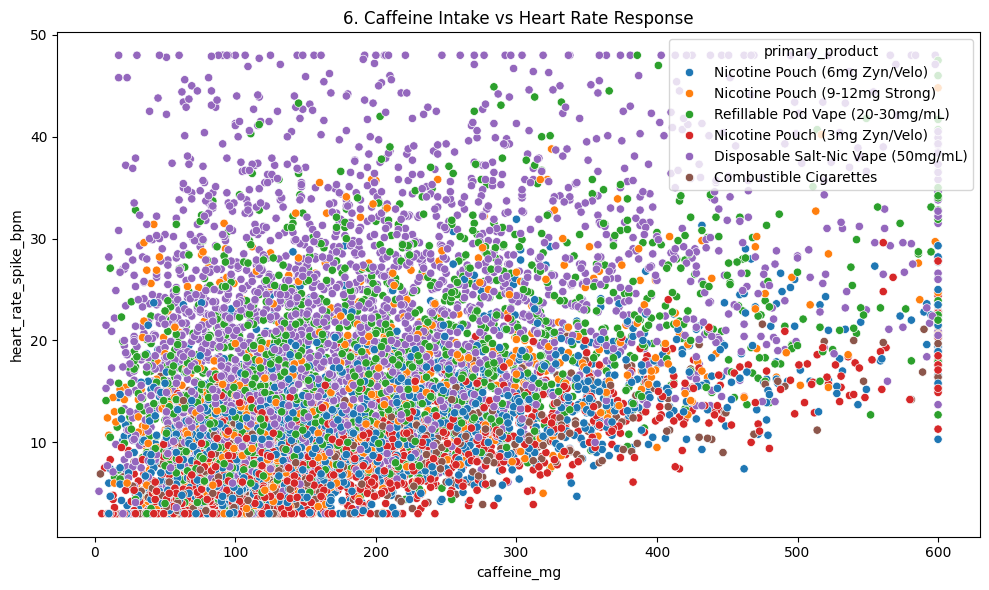

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='caffeine_mg', y='heart_rate_spike_bpm', hue='primary_product')
plt.title(f'{plot_no}. Caffeine Intake vs Heart Rate Response')
show_fig()
plot_no += 1

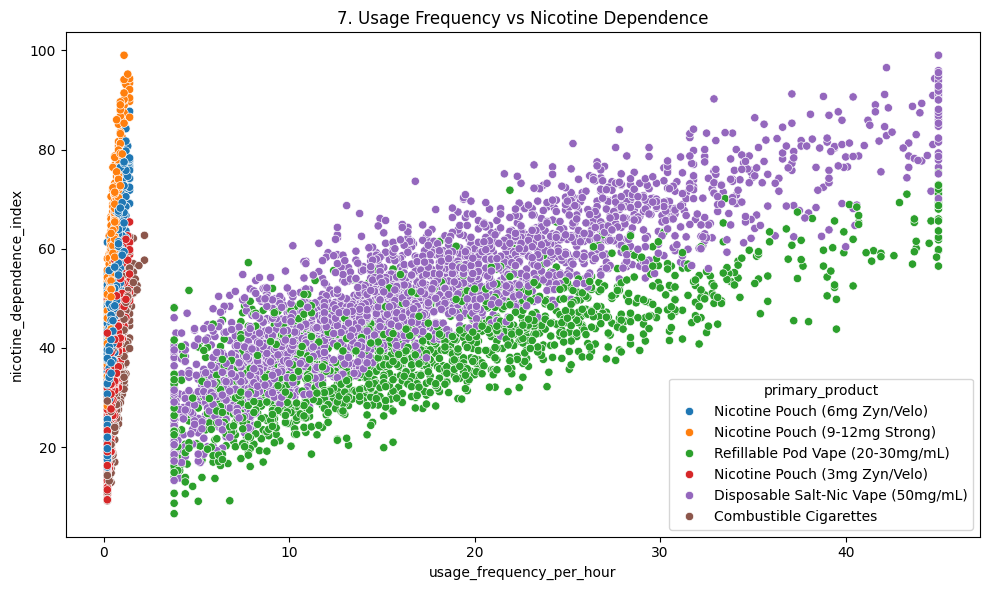

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='usage_frequency_per_hour', y='nicotine_dependence_index', hue='primary_product')
plt.title(f'{plot_no}. Usage Frequency vs Nicotine Dependence')
show_fig()
plot_no += 1

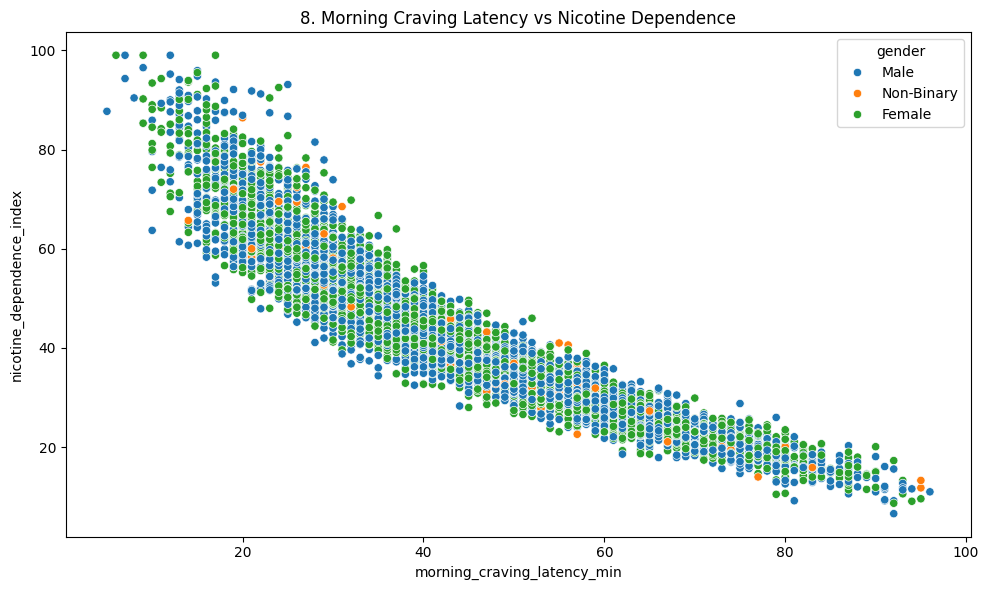

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='morning_craving_latency_min', y='nicotine_dependence_index', hue='gender')
plt.title(f'{plot_no}. Morning Craving Latency vs Nicotine Dependence')
show_fig()
plot_no += 1

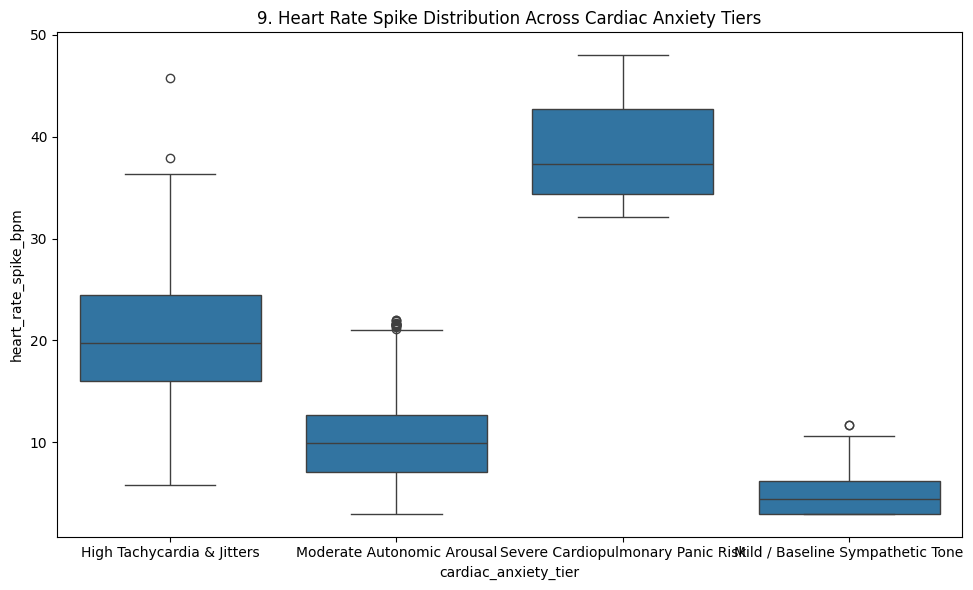

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='cardiac_anxiety_tier', y='heart_rate_spike_bpm')
plt.title(f'{plot_no}. Heart Rate Spike Distribution Across Cardiac Anxiety Tiers')
show_fig()
plot_no += 1

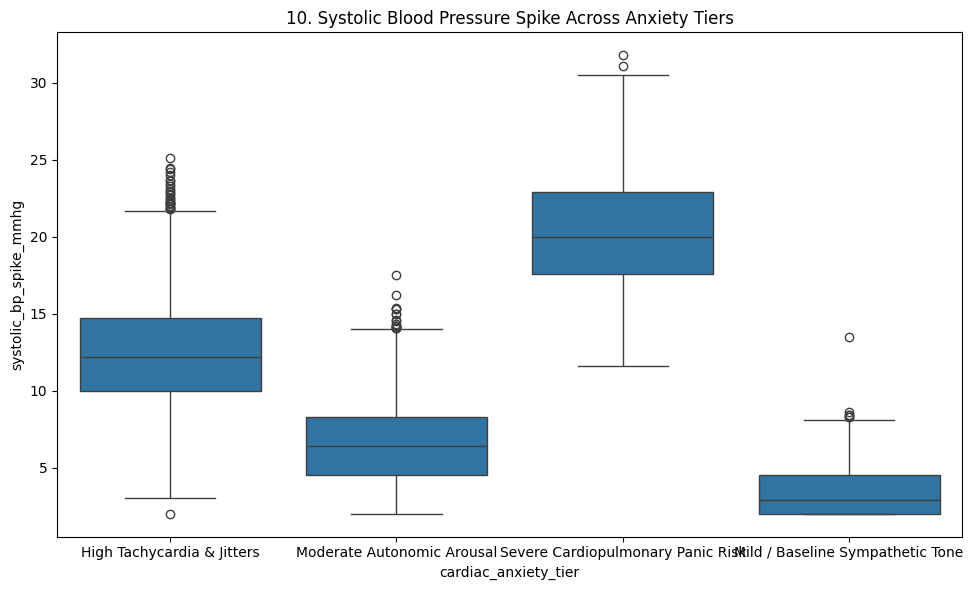

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='cardiac_anxiety_tier', y='systolic_bp_spike_mmhg')
plt.title(f'{plot_no}. Systolic Blood Pressure Spike Across Anxiety Tiers')
show_fig()
plot_no += 1

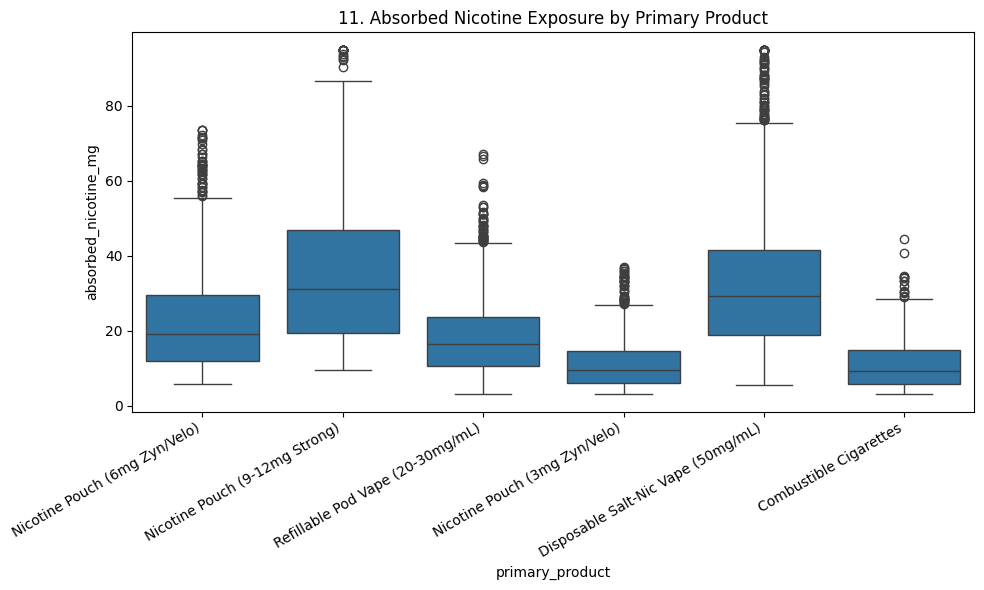

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='primary_product', y='absorbed_nicotine_mg')
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Absorbed Nicotine Exposure by Primary Product')
show_fig()
plot_no += 1

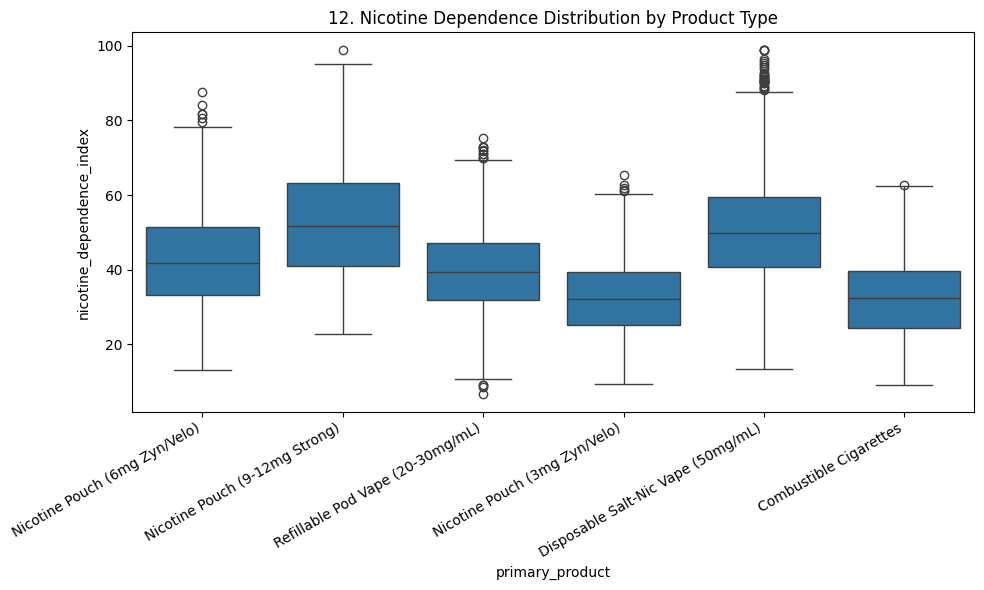

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='primary_product', y='nicotine_dependence_index')
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Nicotine Dependence Distribution by Product Type')
show_fig()
plot_no += 1

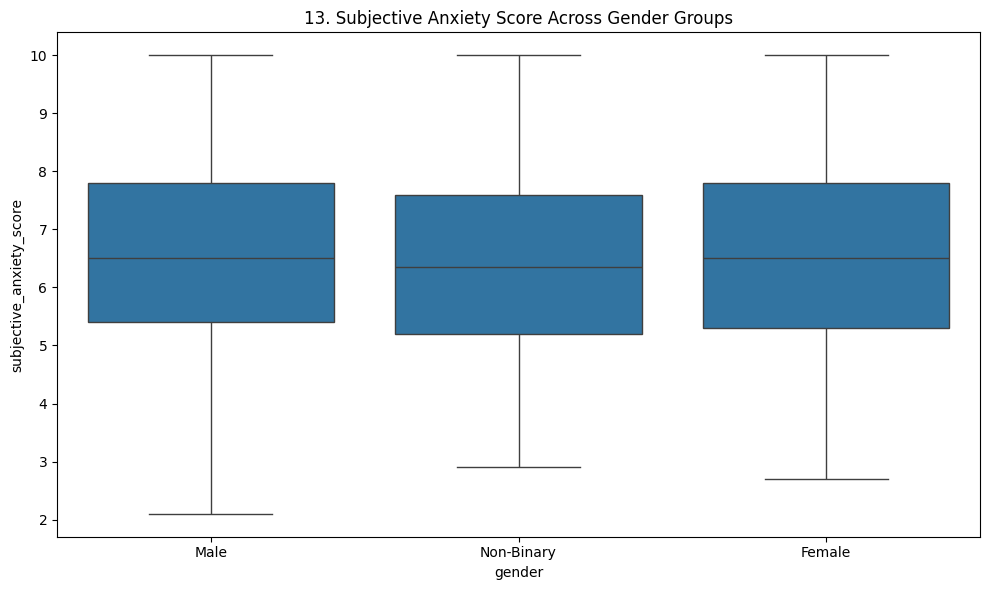

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='subjective_anxiety_score')
plt.title(f'{plot_no}. Subjective Anxiety Score Across Gender Groups')
show_fig()
plot_no += 1

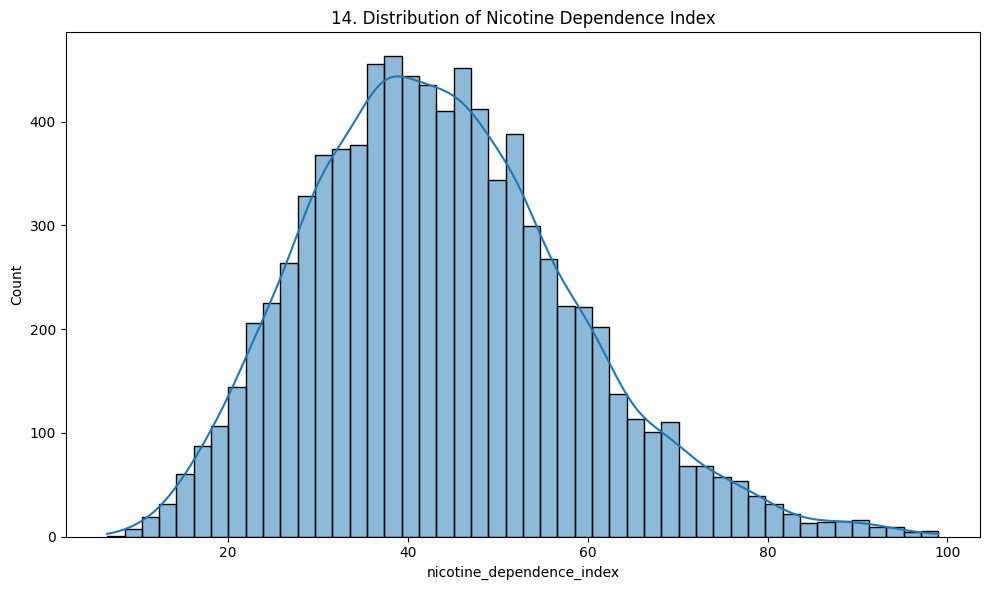

In [26]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='nicotine_dependence_index', kde=True)
plt.title(f'{plot_no}. Distribution of Nicotine Dependence Index')
show_fig()
plot_no += 1

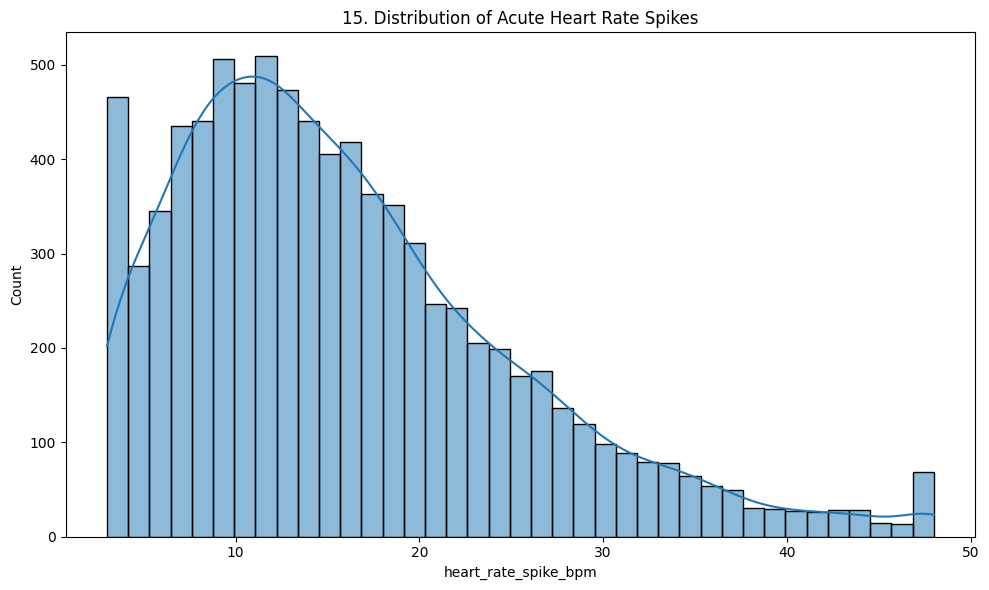

In [27]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='heart_rate_spike_bpm', kde=True)
plt.title(f'{plot_no}. Distribution of Acute Heart Rate Spikes')
show_fig()
plot_no += 1

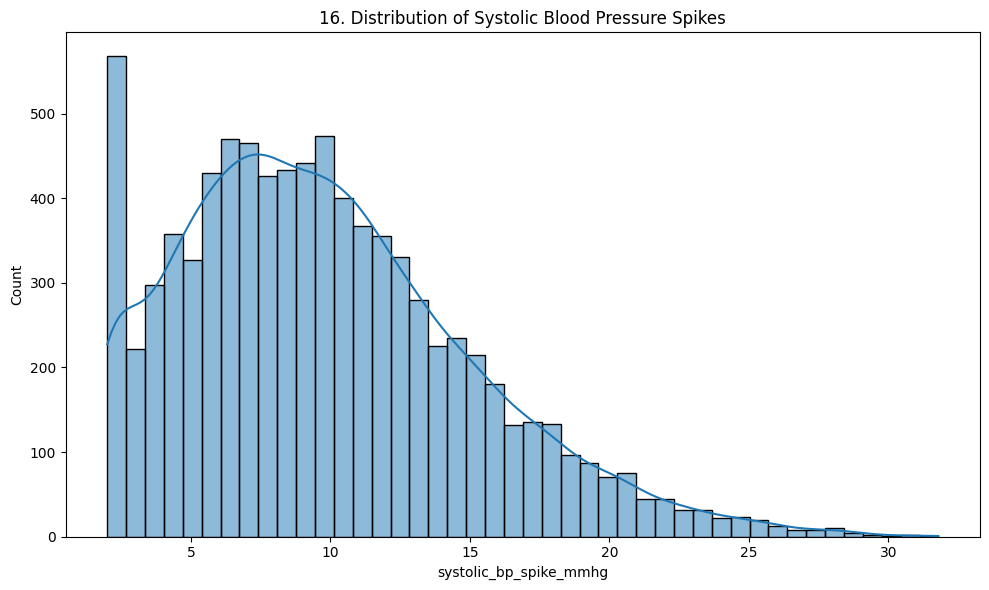

In [28]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='systolic_bp_spike_mmhg', kde=True)
plt.title(f'{plot_no}. Distribution of Systolic Blood Pressure Spikes')
show_fig()
plot_no += 1

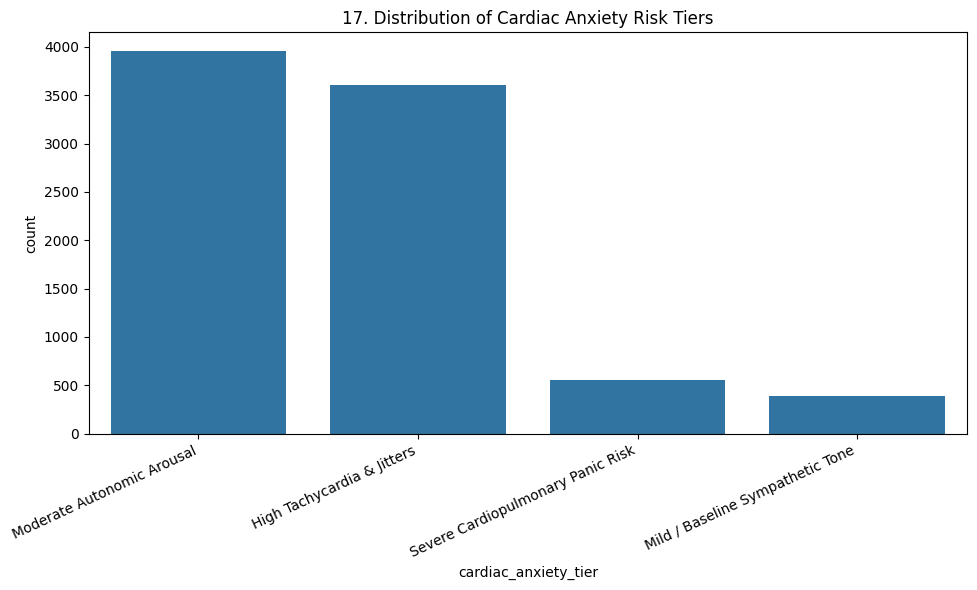

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='cardiac_anxiety_tier', order=df['cardiac_anxiety_tier'].value_counts().index)
plt.xticks(rotation=25, ha='right')
plt.title(f'{plot_no}. Distribution of Cardiac Anxiety Risk Tiers')
show_fig()
plot_no += 1

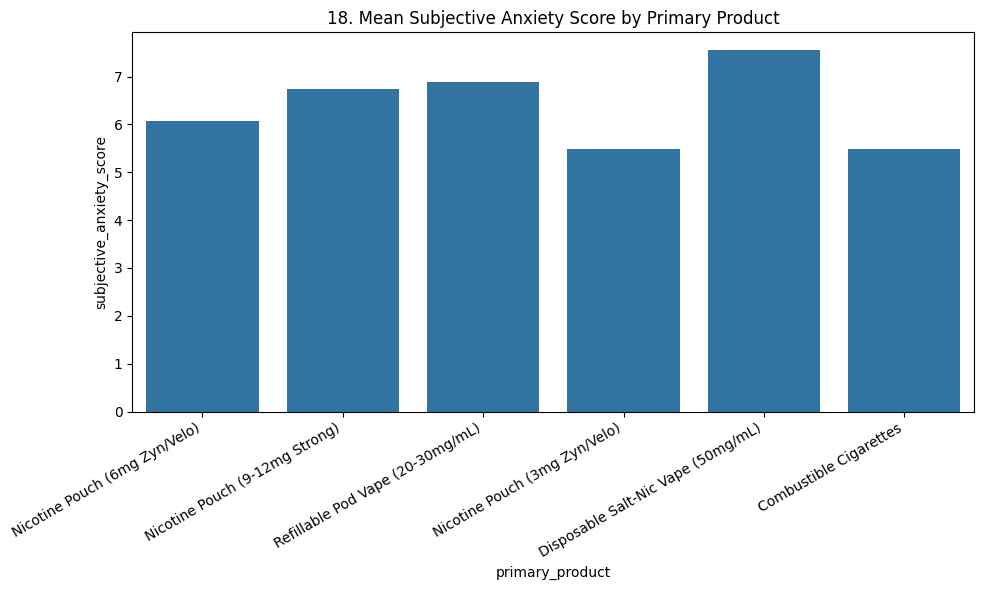

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='primary_product', y='subjective_anxiety_score', estimator='mean', errorbar=None)
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Mean Subjective Anxiety Score by Primary Product')
show_fig()
plot_no += 1

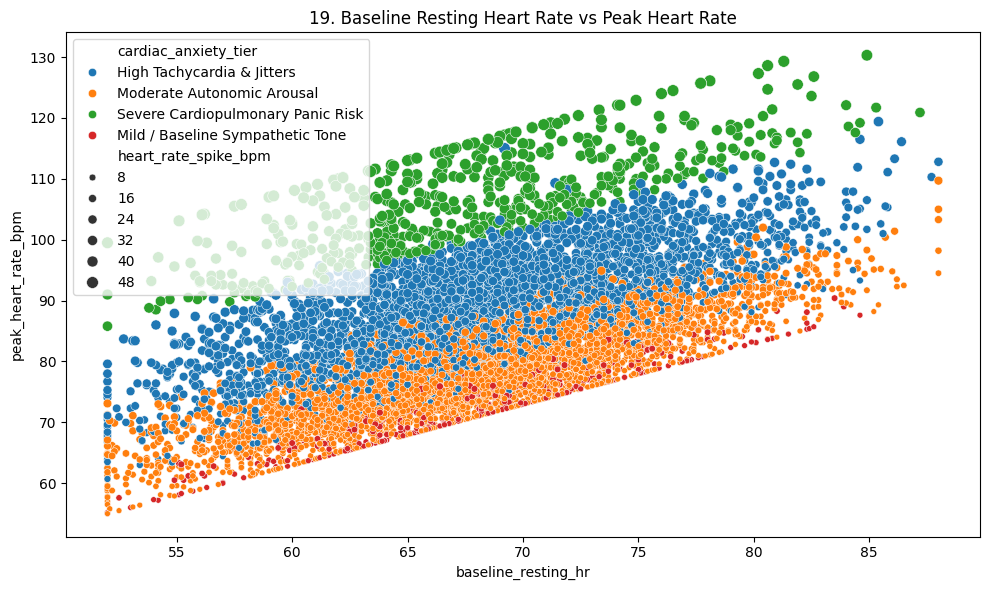

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='baseline_resting_hr', y='peak_heart_rate_bpm', size='heart_rate_spike_bpm', hue='cardiac_anxiety_tier')
plt.title(f'{plot_no}. Baseline Resting Heart Rate vs Peak Heart Rate')
show_fig()
plot_no += 1

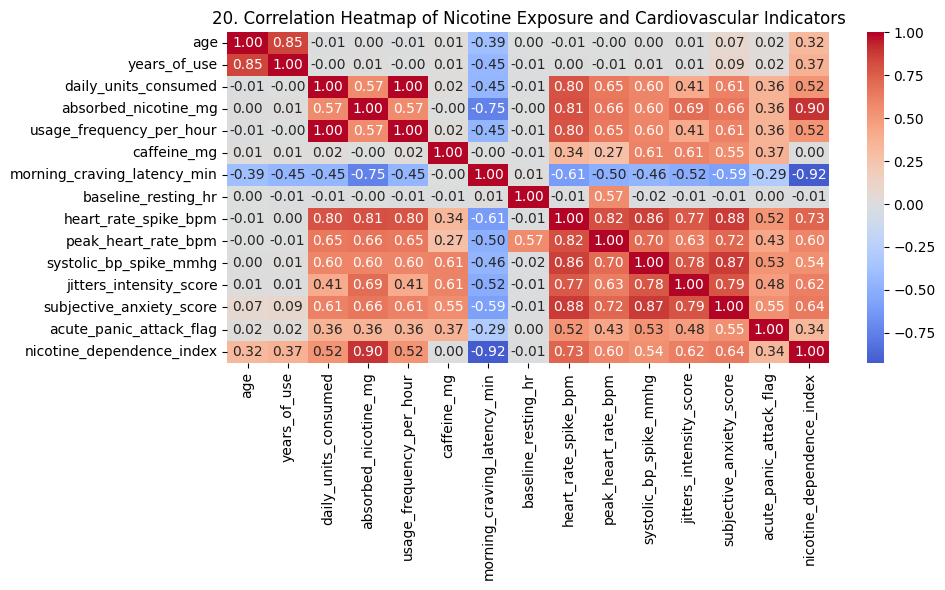

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Nicotine Exposure and Cardiovascular Indicators')
show_fig()
plot_no += 1

# Model Training

## Prepare features and target

In [33]:
X = df.drop(columns=['cardiac_anxiety_tier', 'user_id'])
y = df['cardiac_anxiety_tier']

## Identify categorical and numerical features

In [34]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['number']).columns

## Preprocess numerical features with scaling and categorical features with one-hot encoding

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## Create a supervised Logistic Regression classification model

In [36]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

## Split the dataset into training and testing sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train the supervised model

In [38]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'years_of_use', 'daily_units_consumed', 'absorbed_nicotine_mg',
       'usage_frequency_per_hour', 'caffeine_mg',
       'morning_craving_latency_min', 'baseline_resting_hr',
       'heart_rate_spike_bpm', 'peak_heart_rate_bpm', 'systolic_bp_spike_mmhg',
       'jitters_intensity_score', 'subjective_anxiety_score',
       'acute_panic_attack_flag', 'nicotine_dependence_index'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'primary_product'], dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=2000))])

## Generate predictions on unseen test data

In [39]:
y_pred = model.predict(X_test)

## Calculate and print the classification accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 0.9829
Model Accuracy: 98.29%


## Display the confusion matrix

In [41]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

## Plot actual versus predicted classification results

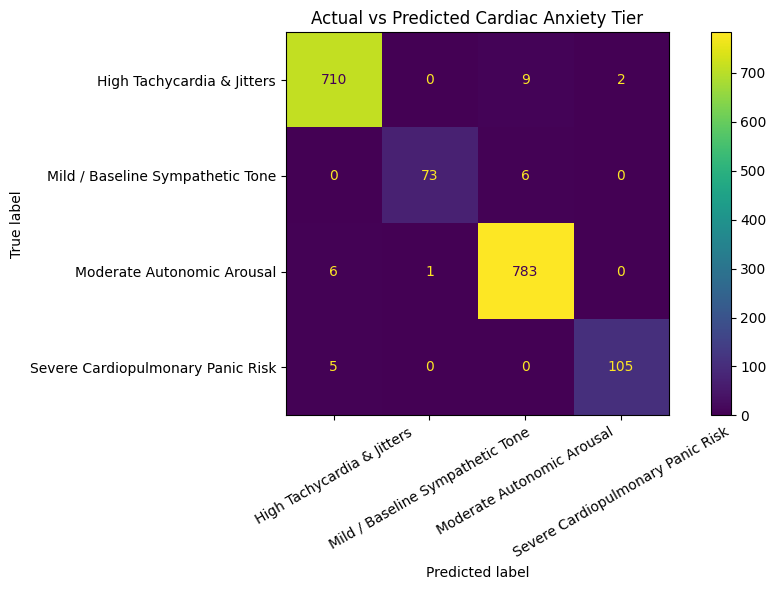

In [42]:
fig = plt.figure(figsize=(10,6))
disp.plot(ax=plt.gca(), xticks_rotation=30)
plt.title('Actual vs Predicted Cardiac Anxiety Tier')
plt.tight_layout()
plt.show()